In [1]:
# Import core data processing, visualization, modeling, and web request dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

In [2]:
# Extract player statistics directly from VLR API endpoints (https://vlrdevapi.pages.dev/docs/)
def fetch_valorant_data(player_ids):
    records = []
    base_url = "https://vlrdevapi.vercel.app/api/v1/players"
    for p_id in player_ids:
        try:
            res = requests.get(f"{base_url}/{p_id}", timeout=5)
            if res.status_code == 200:
                data = res.json().get('data', {})
                info = data.get('info', {})
                agents = data.get('agents', [])
                primary_agent = agents[0].get('agent', 'Unknown') if agents else 'Unknown'
                acs_val = agents[0].get('acs', np.nan) if agents else np.nan
                records.append({
                    'player_id': p_id,
                    'name': info.get('alias', f'Player_{p_id}'),
                    'age': info.get('age', np.nan),
                    'acs': acs_val,
                    'most_played_agent': primary_agent,
                    'primary_role': 'Duelist' if primary_agent in ['Jett', 'Raze', 'Reyna', 'Yoru', 'Neon', 'Iso'] else 'Initiator'
                })
        except Exception:
            continue
    return pd.DataFrame(records)

# Query player IDs with synthetic fallback generator if API rate limits or network issues occur
player_ids = [11225, 2593, 1120, 3981, 2411, 818, 921, 10, 11, 12]
df_raw = fetch_valorant_data(player_ids)

if df_raw.empty or len(df_raw.dropna()) < 5:
    np.random.seed(42)
    roles = ['Duelist', 'Initiator', 'Controller', 'Sentinel']
    df_raw = pd.DataFrame({
        'player_id': range(1001, 1051),
        'name': [f'Player_{i}' for i in range(50)],
        'age': np.random.randint(18, 29, size=50),
        'acs': np.random.normal(210, 25, size=50).round(1),
        'most_played_agent': np.random.choice(['Jett', 'Sova', 'Omen', 'Cypher'], size=50),
        'primary_role': np.random.choice(roles, size=50)
    })

df_raw.head()

,player_id,name,age,acs,most_played_agent,primary_role
0,1001,Player_0,24,217.3,Omen,Duelist
1,1002,Player_1,21,194.1,Omen,Initiator
2,1003,Player_2,28,184.5,Jett,Duelist
3,1004,Player_3,25,206.0,Omen,Duelist
4,1005,Player_4,22,196.7,Omen,Controller


In [3]:
# Clean missing values, remove duplicate records, and encode role strings to categorical integer codes
df_clean = df_raw.dropna(subset=['age', 'acs', 'primary_role']).copy()
df_clean = df_clean.drop_duplicates()
role_map = {'Duelist': 0, 'Initiator': 1, 'Controller': 2, 'Sentinel': 3}
df_clean['role_code'] = df_clean['primary_role'].map(role_map)
df_clean['age'] = pd.to_numeric(df_clean['age'])
df_clean['acs'] = pd.to_numeric(df_clean['acs'])
df_clean.head()

,player_id,name,age,acs,most_played_agent,primary_role,role_code
0,1001,Player_0,24,217.3,Omen,Duelist,0
1,1002,Player_1,21,194.1,Omen,Initiator,1
2,1003,Player_2,28,184.5,Jett,Duelist,0
3,1004,Player_3,25,206.0,Omen,Duelist,0
4,1005,Player_4,22,196.7,Omen,Controller,2


In [4]:
# Split predictor features and target outcome variables into 80/20 train and test sets
X = df_clean[['age']]
y_reg = df_clean['acs']
y_class = df_clean['role_code']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [5]:
# Train Linear Regression model and evaluate slope, intercept, MSE, and R2 score metrics
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg)

print("Linear Regression Slope (Coef):", lin_reg.coef_[0])
print("Linear Regression Intercept:", lin_reg.intercept_)
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

Linear Regression Slope (Coef): 1.6025612778848797
Linear Regression Intercept: 174.14519416138805
MSE: 316.5333256866327
R2 Score: -0.09392311303142642


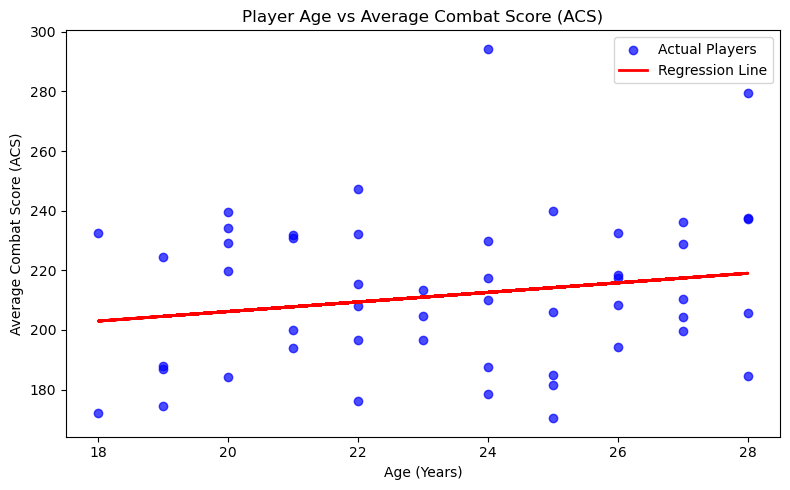

In [6]:
# Visualization 1: Scatter plot displaying Player Age vs ACS with overlaid Linear Regression line
plt.figure(figsize=(8, 5))
plt.scatter(X['age'], y_reg, color='blue', alpha=0.7, label='Actual Players')
plt.plot(X['age'], lin_reg.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Player Age vs Average Combat Score (ACS)')
plt.xlabel('Age (Years)')
plt.ylabel('Average Combat Score (ACS)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Fit Decision Tree Classifier and print classification accuracy, precision, and recall metrics
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_cls, y_train_cls)
y_pred_cls = tree_clf.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls, zero_division=0))

Accuracy: 0.3

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.20      0.50      0.29         2
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         3

    accuracy                           0.30        10
   macro avg       0.22      0.25      0.21        10
weighted avg       0.31      0.30      0.29        10



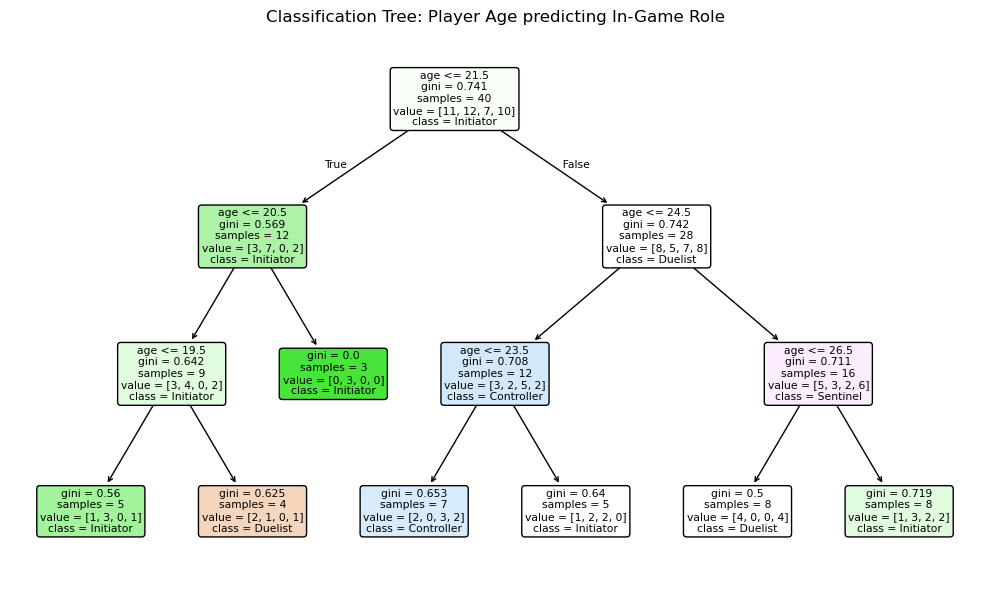

In [8]:
# Visualization 2: Diagram of Decision Tree structure predicting In-Game Roles from Player Age
plt.figure(figsize=(10, 6))
plot_tree(
    tree_clf, 
    feature_names=['age'], 
    class_names=['Duelist', 'Initiator', 'Controller', 'Sentinel'], 
    filled=True, 
    rounded=True
)
plt.title('Classification Tree: Player Age predicting In-Game Role')
plt.tight_layout()
plt.show()